<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# <font color=18453B>CMSE 801 - Day 10</font>
## Planning and visualizing compartmental models
### September 30, 2024

## General Course Announcements

* **Reminder**: Homework 2 is on the course website and is due by **11:59 on Friday, October 11**.
* Quiz 1 is **today** during the last 30 minutes of class.

## Questions/comments from Day 10 PCA

* Still running into some issues with using `solve_ivp` -- **we'll revisit some basic components of using `solve_ivp` in a moment**.
* Some questions about the specific "Viral Kinetics" example used in the PCA, so **we'll take a look at that**
    * Related: questions about making the 3D plot



## Let's revisit how we use `solve_ivp` and specifically the `args` argument

<img src="https://github.com/msu-cmse-courses/cmse801-supplemental/blob/main/images/solve_ivp_structure.png?raw=true"  alt="solve-ivp-structure" border="0" width=1200>

## If we want to pass in model parameters without having to change the `derivs` function, we can do that, but we need to define them in the function arguments

In [1]:
def derivs(time,curr_vals, A, m):
    
    # Declare any unchanging parameters
    g = -9.81 # m/s^2
    
    # Unpack the current values of the variables we wish to "update" from the curr_vals list
    h, v = curr_vals
    
    # Right-hand side of odes, which are used to compute the derivative
    dhdt = v
    dvdt = g + (-0.65 * A * v * abs(v))/m
    
    return dhdt, dvdt

### Then, when we call `solve_ivp`, we need to pass these through via the `args` argument

In [2]:
import numpy as np
from scipy.integrate import solve_ivp

# Declare Variables for initial conditions
h0 = 2000 # meters ### MODIFIED CODE
v0 = 0 # m/s
g = -9.81 # m/s^2
tmax = 30 # seconds
dt = 0.1 # seconds

# Define the time array
time = np.arange(0, tmax + dt, dt)

# Store the initial values in a list
init = [h0, v0]

# Define the model parameters needed for the derivs function
A = 0.4 # m^2
m = 80.0 # kg

# Solve the odes with solve_ivp
sol = solve_ivp(derivs, (0,tmax),init,t_eval = time, args=(A, m))

## And, of course, we need to them unpack the result to visualize it

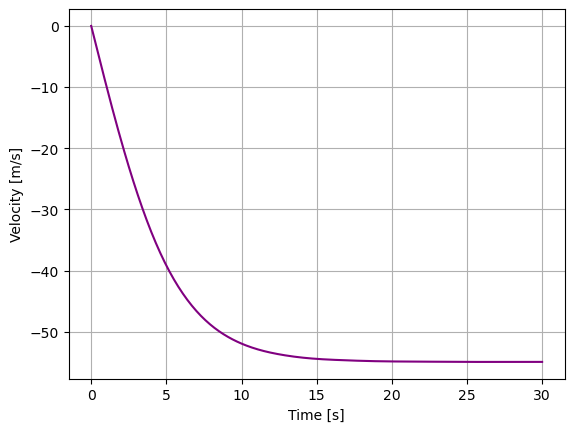

In [5]:
import matplotlib.pyplot as plt

#print(sol.y)

# Unpack the results stored in the solution variable, "sol"
h = sol.y[0,:]
v = sol.y[1,:]
t = sol.t

# Plot the results we unpacked from "sol" for velocity
plt.figure(2)
plt.plot(t, v, color = 'purple')
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.grid()

## Let's walk through the pieces for the viral kinetics problem

<br>
<img src="http://www.frontiersin.org/files/Articles/32842/fmicb-03-00319-HTML/image_m/fmicb-03-00319-g001.jpg" width = 600>

The model was:

$$\frac{dT}{dt} = -\beta TV,$$ 

$$\frac{dI}{dt} = \beta TV - \delta I,$$ 

$$\frac{dV}{dt} = pI - rV.$$


### Remember: the order of our values and derivatives matters!!

In [8]:
# First thing I want to do is turn the equations into code
def derivs(t, curr_vals, beta, delta, p, r):
    # unpack list of incoming variables (which are stored in curr_vals)
    target = curr_vals[0]
    infected = curr_vals[1]
    virion = curr_vals[2]

    # use variables to compute derivatives on the right-hand-side of the above equations
    # example: dTdt = < equation from above >
    dTdt = -beta*target*virion
    dIdt = (beta*target*virion) - (delta*infected)
    
    dVdt = (p*infected) - (r*virion)

    # return the derivatives, one for each equation
    return dTdt, dIdt, dVdt

In [9]:
# Then I need to set up my initial conditions
target_0 = 4e8
infected_0 = 0.0
virions_0 = 1.0
# Here we put them all into a list so that they can be passed to solve_ivp
initial = [target_0, infected_0, virions_0]

In [10]:
# Also need to define the times that I want my solution for
time = np.linspace(0, 10., 1000)

In [11]:
# And define my model parameters
beta = 1e-5
delta = 4.0
p = 1e-2
r = 1

In [12]:
# finally, I can call solve_ivp and unpack my solutions
sol = solve_ivp(derivs, (time[0], time[-1]), initial,
                t_eval=time, args=(beta, delta, p, r))
tar = sol.y[0, :]
inf = sol.y[1, :]
vir = sol.y[2, :]

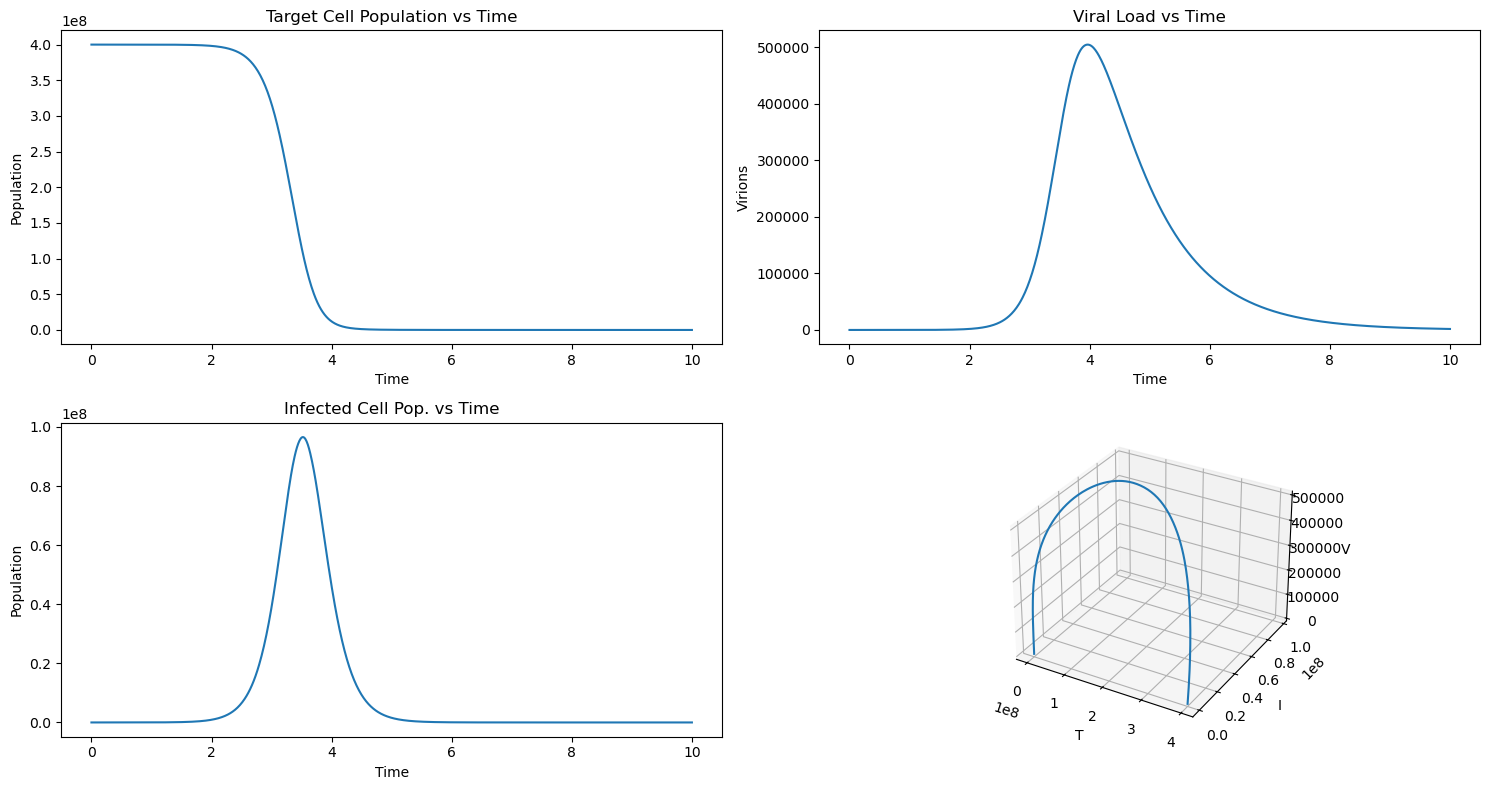

In [13]:
# With my solutions, I can visualize the result
#This initializes a figure object
plt.figure(figsize = (15,8))

plt.subplot(2,2,1)
plt.plot(time,tar)
plt.title('Target Cell Population vs Time')
plt.xlabel('Time')
plt.ylabel('Population')

plt.subplot(2,2,2)
plt.plot(time, vir)
plt.title('Viral Load vs Time')
plt.xlabel('Time')
plt.ylabel('Virions')

plt.subplot(2,2,3)
plt.plot(time, inf)
plt.title('Infected Cell Pop. vs Time')
plt.xlabel('Time')
plt.ylabel('Population')

ax4 = plt.subplot(2,2,4, projection = '3d')
plt.plot(tar, inf, vir)
ax4.set_xlabel("T")
ax4.set_ylabel("I")
ax4.set_zlabel("V")

# Make sure to call this last. This command resizes the spaces between your plots to try to avoid overlap.
plt.tight_layout()

## Goals for today
* Spend some time **not coding** and trying to carefully think through how you might build some compartmental models
* Think about what the compartments are and how they interact. **What defines how they evolve over time?** (i.e. what might their system of ODEs look like?)

## Looking forward - Day 11 PCA: Look at another compartmental model example and practice using solve_ivp some more -- modeling a zombie apocalypse.

* You'll explore a model for how a zombie outbreak might occur and evolve for a variety of model variations and parameters.
* You'll use `solve_ivp` some more.